In [1]:
import os
import sys

if "google.colab" in sys.modules:
    !git clone https://github.com/paulphilip-louis/attention-tracker.git /content/repo
    os.chdir("/content/repo")
    #!uv pip compile pyproject.toml -o requirements.txt
    #!pip install -r requirements.txt

fatal: destination path '/content/repo' already exists and is not an empty directory.


# Imports

In [4]:
import numpy as np
import matplotlib.pyplot
import torch as t
from utils import utils

from transformers import AutoTokenizer, AutoModelForCausalLM
from transformer_lens import HookedTransformer

In [13]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("Loading model...")
model = utils.load_model(MODEL_NAME)


Loading model...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model Qwen/Qwen2.5-1.5B-Instruct into HookedTransformer
Moving model to device:  cuda


In [14]:
normal_dataset, attack_dataset = utils.generate_dataset()

## Visualizing attention from last token to instruction

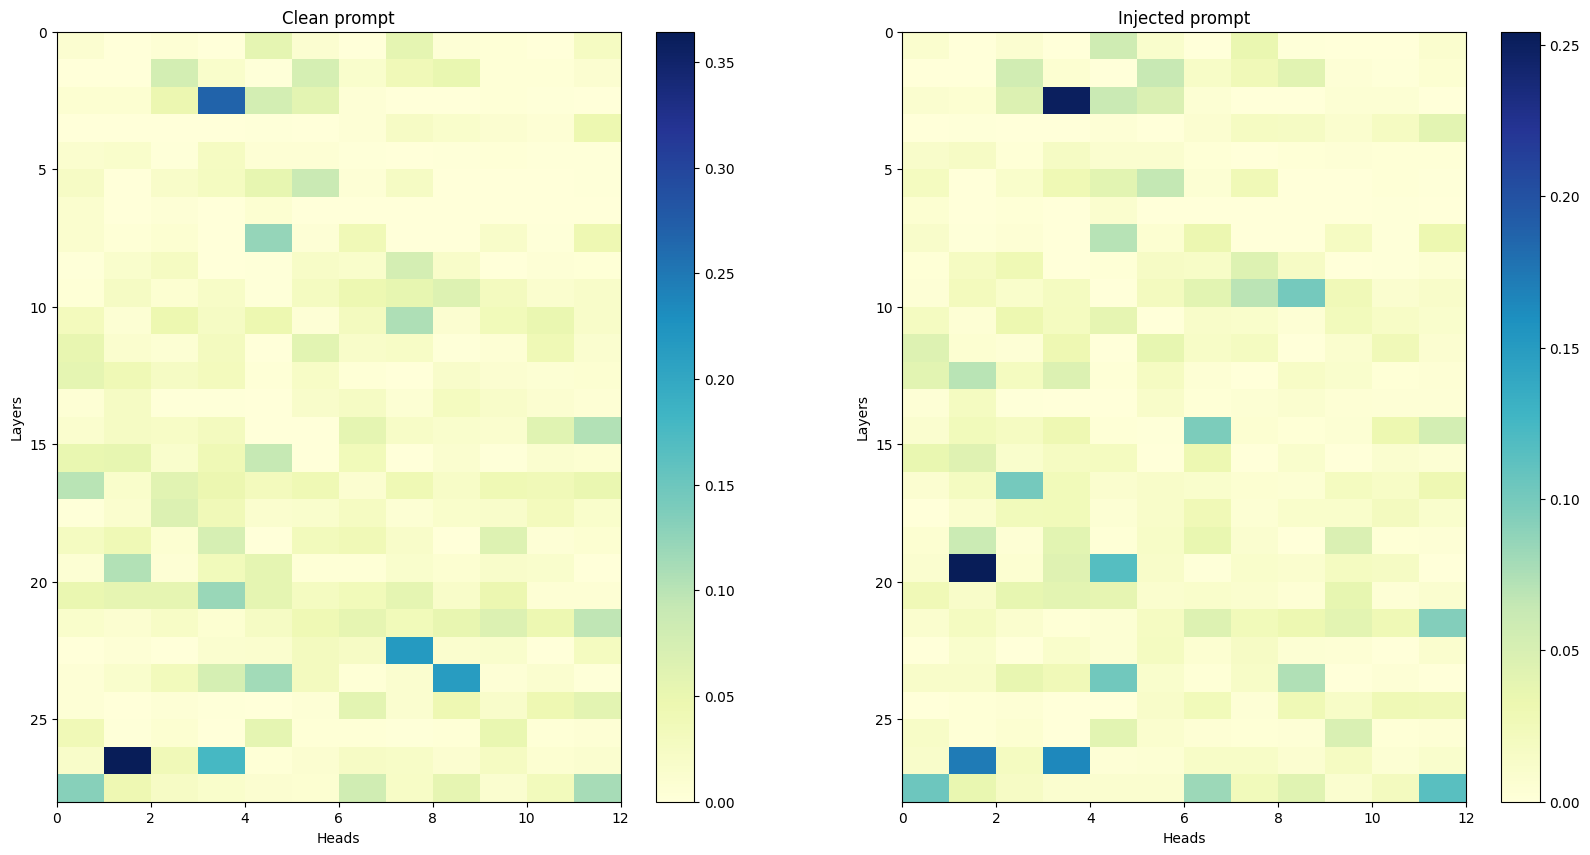

In [15]:
normal_attn_scores = utils.get_activations(model, normal_dataset[0])
injected_attn_scores = utils.get_activations(model, attack_dataset[0])

utils.plot_attn_by_layer(normal_attn_scores, injected_attn_scores)

## Visualizing average attention from last token to each token

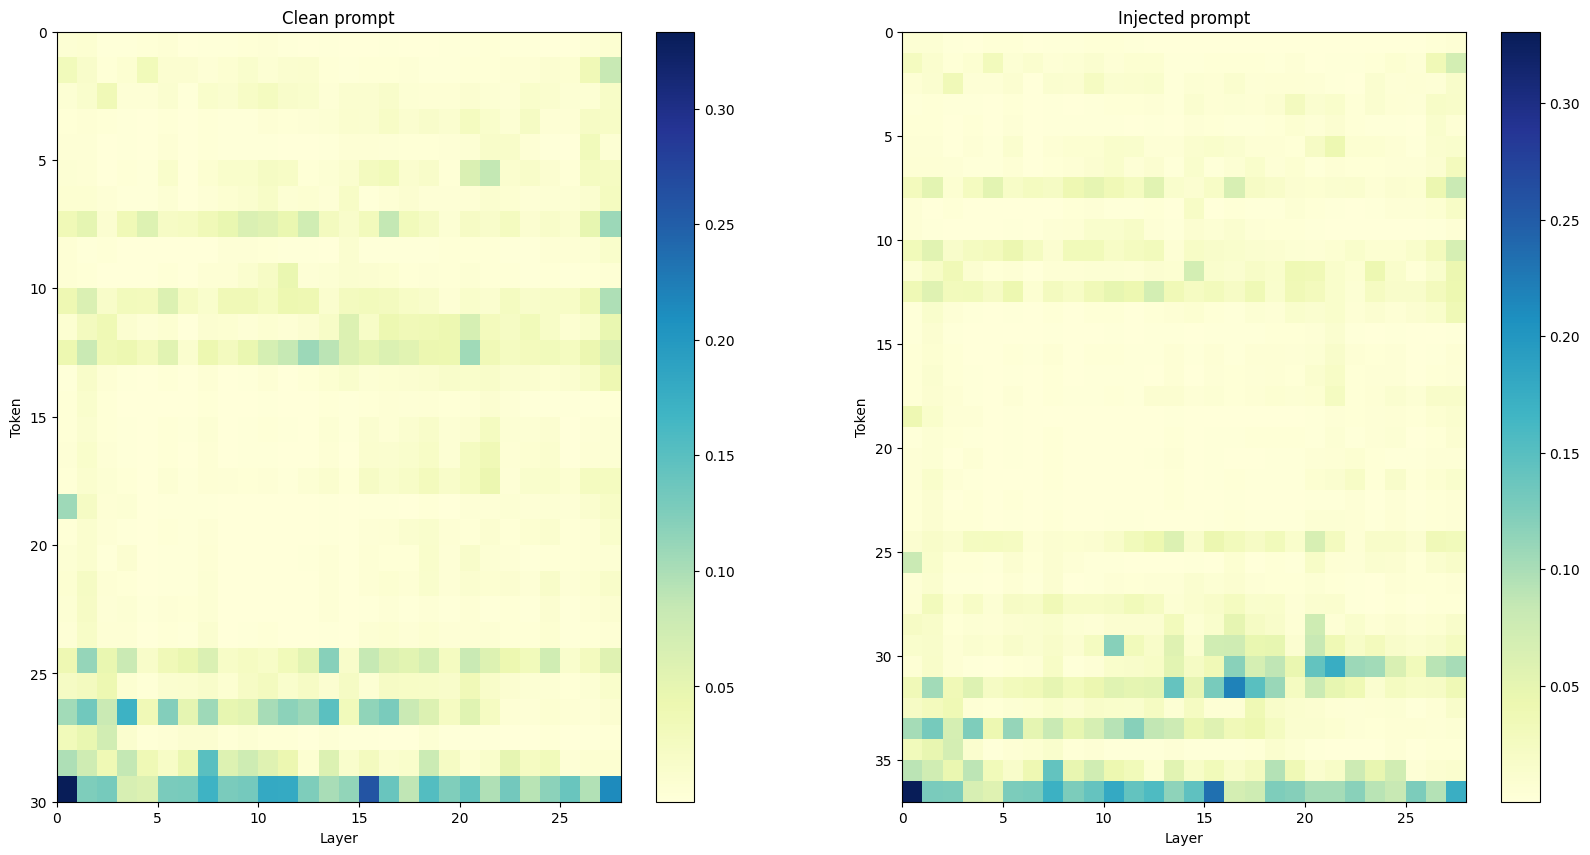

In [16]:
norm_attn_by_token = utils.get_activations_by_token(model, normal_dataset[0])
attack_attn_by_token = utils.get_activations_by_token(model, attack_dataset[0])

utils.plot_attn_by_token(norm_attn_by_token, attack_attn_by_token)

# Identifying important heads

100%|██████████| 30/30 [00:04<00:00,  7.03it/s]


100%|██████████| 30/30 [00:04<00:00,  6.05it/s]


Computing head scores...


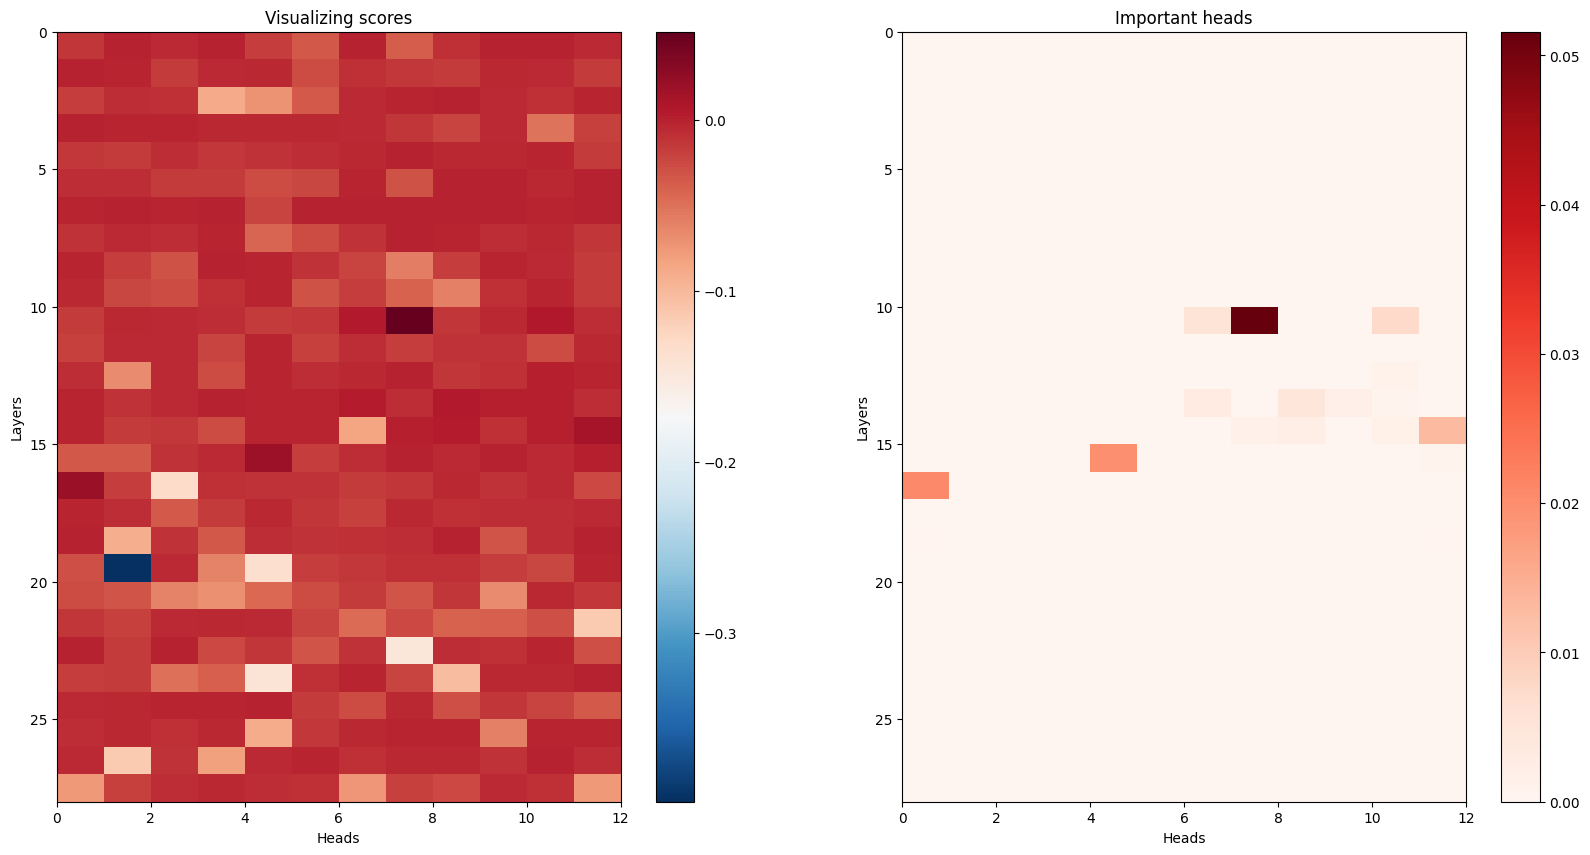

In [17]:
scores = utils.score_heads(model, normal_dataset, attack_dataset, k=3)
utils.plot_head_scores(scores)

In [18]:
H_i = utils.important_heads(scores)

# Testing performance

In [19]:
auroc, accuracy = utils.run_on_benchmark(model, H_i, threshold=0.2, benchmark_name="opi")

Loading dataset...
Building prompts
Computing focus scores for safe dataset...


100%|██████████| 1000/1000 [02:33<00:00,  6.51it/s]


Computing focus scores for injected dataset...


100%|██████████| 1000/1000 [03:04<00:00,  5.41it/s]


In [20]:
auroc

1.0